In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)

In [2]:
import os

LABELS_CSV = 'train_labels.csv'
TEST_LABELS_CSV = 'test_labels.csv'

if os.path.isdir('/content'):
    os.chdir('/content')
    missing = [f for f in (LABELS_CSV, TEST_LABELS_CSV) if not os.path.exists(f)]
    if missing:
        DRIVE_DIR = '/content/drive/MyDrive'                            # loose CSVs in Drive -- adjust if they're in a subfolder
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'     # fallback: pull them out of the data zip

        from google.colab import drive
        drive.mount('/content/drive')

        for csv in missing:
            drive_csv = os.path.join(DRIVE_DIR, csv)
            if os.path.exists(drive_csv):
                get_ipython().system(f'cp "{drive_csv}" .')
            elif os.path.exists(DRIVE_ZIP_PATH):
                # pull just this CSV out of the zip (skips the images)
                get_ipython().system(f'unzip -qo "{DRIVE_ZIP_PATH}" {csv}')
            assert os.path.exists(csv), f"Couldn't find {csv} in {DRIVE_DIR} or inside {DRIVE_ZIP_PATH}"
    print('labels ready in', os.getcwd())

Mounted at /content/drive
labels ready in /content


In [3]:
train_labels = pd.read_csv(LABELS_CSV)

# Training data

In [4]:
train_labels

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
1,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
2,ISIC_0076545,IP_9802602,male,55.0,upper extremity,unknown,benign,0
3,ISIC_0082348,IP_7684360,male,55.0,torso,unknown,benign,0
4,ISIC_0085172,IP_1705144,female,50.0,lower extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,female,50.0,torso,unknown,benign,0
6860,ISIC_9990676,IP_3686214,female,55.0,lower extremity,nevus,benign,0
6861,ISIC_9991394,IP_2321962,female,30.0,torso,unknown,benign,0
6862,ISIC_9991967,IP_2507276,male,70.0,lower extremity,nevus,benign,0


In [5]:
print(f"Number of malignant cases: {len(train_labels[train_labels["target"] == 1])}")

Number of malignant cases: 128


In [6]:
train_labels.describe()

,age_approx,target
count,6864.000000,6864.000000
mean,48.944493,0.018648
std,14.401600,0.135288
min,15.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


In [7]:
train_labels.isna().sum()

,0
image_name,0
patient_id,0
sex,0
age_approx,0
anatom_site_general_challenge,196
diagnosis,0
benign_malignant,0
target,0


In [8]:
print(f"Number of unique patients: {len(train_labels) - train_labels["patient_id"].duplicated().sum()}")

Number of unique patients: 422


In [9]:
print(f"Does every 'melanoma' diagnosis correspond to a '1' in a target: {(train_labels[train_labels["diagnosis"] == "melanoma"]["target"] == 1).all()}")

Does every 'melanoma' diagnosis correspond to a '1' in a target: True


Text(0.5, 1.0, 'Age Distribution: Benign vs Malignant')

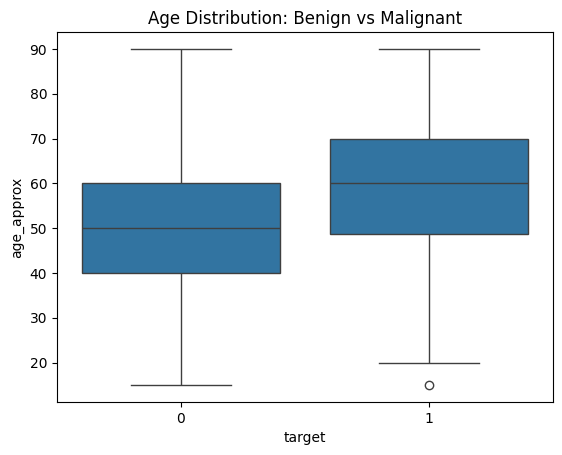

In [10]:
# Malignant cases show a visibly higher median age than benign cases in this boxplot.
sns.boxplot(data=train_labels, x='target', y='age_approx').set_title("Age Distribution: Benign vs Malignant")

Hypothesis testing: Seeing if having a malignant region increases the chances of having more malignant spots

In [11]:
unique_patients = train_labels.groupby("patient_id")["target"].agg(["sum", "count"])
unique_patients.describe()

,sum,count
count,422.000000,422.000000
mean,0.303318,16.265403
std,0.756877,16.568455
min,0.000000,3.000000
25%,0.000000,5.000000
50%,0.000000,12.000000
75%,0.000000,21.750000
max,8.000000,115.000000


In [12]:
# Patients who have 115 entries
unique_patients[unique_patients['count'] == 115]

,sum,count
patient_id,,
IP_4382720,0,115
IP_4938382,1,115


In [13]:
# Patients with more than 1 melanoma spot
unique_patients[unique_patients['sum'] > 1]

,sum,count
patient_id,,
IP_0957064,2,3
IP_1023029,2,38
IP_1122600,2,16
IP_1512731,2,37
IP_2101945,2,17
IP_2412574,5,23
IP_2986217,3,7
IP_3010556,3,4
IP_3045056,2,4


<Axes: title={'center': 'Melanoma Patients Count by Sum'}, xlabel='Melanoma Counts', ylabel='Number of patients'>

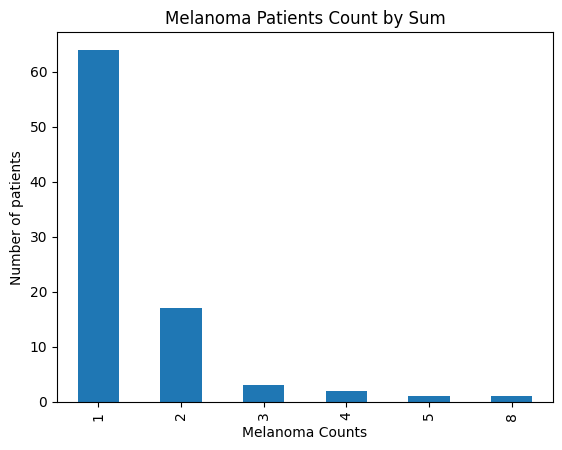

In [14]:
melanoma_patients = unique_patients[unique_patients['sum'] > 0]
melanoma_patients.groupby("sum")["sum"].count().plot.bar(
    xlabel = "Melanoma Counts",
    ylabel = "Number of patients",
    title = "Melanoma Patients Count by Sum"
)

In [15]:
n_simulations = 10000
p = train_labels['target'].mean()  # overall per-lesion malignancy rate
lesion_counts = unique_patients['count'].values

rng = np.random.default_rng(42)
simulated_counts = []

for _ in range(n_simulations):
    sim_malignant_per_patient = rng.binomial(lesion_counts, p)
    simulated_counts.append((sim_malignant_per_patient > 1).sum())

simulated_counts = np.array(simulated_counts)
p_value = (simulated_counts >= 24).mean()

print(f"P-value: {p_value:.4f}")
print(f"Simulated mean: {simulated_counts.mean():.2f}, std: {simulated_counts.std():.2f}")

P-value: 0.3075
Simulated mean: 21.52, std: 4.07


We found no statistically significant evidence of within-patient melanoma clustering beyond what independent lesion-level risk would predict (p=0.31, simulation-based test accounting for each patient's lesion count). This means this dataset doesn't provide strong enough evidence to detect one, if it exists

# Preprocessing

In [16]:
missing_site = train_labels[train_labels["anatom_site_general_challenge"].isna()]
print(f"Missing site malignancy rate: {len(missing_site[missing_site["target"] == 1]) / len(missing_site) * 100: .4f}")
recorded_site = train_labels[train_labels["anatom_site_general_challenge"].notna()]
print(f"Recorded site malignancy rate: {len(recorded_site[recorded_site["target"] == 1]) / len(recorded_site) * 100: .4f}")

Missing site malignancy rate:  1.0204
Recorded site malignancy rate:  1.8896


Missing-site rows show a lower raw malignancy rate than recorded-site rows (1.02% vs 1.89%), but a chi-square test found this difference is NOT statistically significant (p=0.5361) with only 196 missing rows, this test likely lacks power to detect a real but modest effect.
We cannot confirm independence, so rather than assume missingness is random (which dropping or mean-imputing would implicitly assume), we keep "missing" as its own explicit category which is the conservative choice when missing-data randomness hasn't been established either way.

In [17]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(train_labels['anatom_site_general_challenge'].isna(), train_labels['target'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(train_labels.groupby(train_labels['anatom_site_general_challenge'].isna())['target'].mean())
print(f"Chi-square p-value: {p:.4f}")

anatom_site_general_challenge
False    0.018896
True     0.010204
Name: target, dtype: float64
Chi-square p-value: 0.5361


In [18]:
train_labels_clean = train_labels.copy()
train_labels_clean["sex"] = train_labels["sex"].map({"male": 1, "female": 0})
train_labels_clean["anatom_site_general_challenge"] = train_labels_clean["anatom_site_general_challenge"].fillna("missing")
train_labels_clean = train_labels_clean.drop(["diagnosis", "benign_malignant"], axis=1)
train_labels_clean

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,target
0,ISIC_0015719,IP_3075186,0,45.0,upper extremity,0
1,ISIC_0074542,IP_4698288,1,25.0,lower extremity,0
2,ISIC_0076545,IP_9802602,1,55.0,upper extremity,0
3,ISIC_0082348,IP_7684360,1,55.0,torso,0
4,ISIC_0085172,IP_1705144,0,50.0,lower extremity,0
...,...,...,...,...,...,...
6859,ISIC_9988492,IP_8173459,0,50.0,torso,0
6860,ISIC_9990676,IP_3686214,0,55.0,lower extremity,0
6861,ISIC_9991394,IP_2321962,0,30.0,torso,0
6862,ISIC_9991967,IP_2507276,1,70.0,lower extremity,0


# Modeling

In [19]:
# Split by patient (not row) to prevent one patient's lesions spanning train/val (leakage).
# Also stratify by whether each patient has ANY malignant lesion, since an unstratified
# split previously produced a skewed val set (1.26% malignant vs 2.06% in train) --
# stratifying brought both sets to ~1.8-2.0%, making evaluation trustworthy.
patient_summary = train_labels_clean.groupby('patient_id')['target'].max()
train_patients, val_patients = train_test_split(patient_summary.index.to_numpy(), test_size=0.2, random_state=80, stratify=patient_summary.values)

train_df = train_labels_clean[train_labels_clean['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df = train_labels_clean[train_labels_clean['patient_id'].isin(val_patients)].reset_index(drop=True)

# Raw features (age, sex, site); each model's pipeline does its own encoding/scaling,
# fitted on training data only
X_train = train_df.drop(columns=["image_name", "patient_id", "target"])
y_train = train_df["target"]
X_val = val_df.drop(columns=["image_name", "patient_id", "target"])
y_val = val_df["target"]

In [20]:
print(f"Train malignant rate: {y_train.mean():.4f}")
print(f"Val malignant rate:   {y_val.mean():.4f}")

Train malignant rate: 0.0183
Val malignant rate:   0.0202


In [21]:
print(f"Train: {y_train.sum()} malignant / {len(y_train)} total")
print(f"Val:   {y_val.sum()} malignant / {len(y_val)} total")

Train: 103 malignant / 5629 total
Val:   25 malignant / 1235 total


ROC-AUC and PR-AUC used instead of accuracy: with ~1.9% malignant rate, a model predicting "benign" for everything would score ~98% accuracy while being clinically useless.
PR-AUC matters more here than ROC-AUC, since it specifically reflects how well the model finds the rare positive (malignant) cases without excessive false positives.

### Age binning

Age-binning: malignancy rate stays flat (~1-1.5%) below age 60, then rises sharply to 4.6-6.6% in older brackets. This non-linear, threshold-like pattern is something tree models (RF, XGBoost) can capture directly through splits, while logistic regression has to fit it with a single linear age coefficient, one reason to compare both families below.

In [22]:
train_labels_clean['age_bin'] = pd.cut(train_labels_clean['age_approx'], bins=[0,30,45,60,75,100])
train_labels_clean.groupby('age_bin')['target'].mean()

/tmp/ipykernel_1304/4107088436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_labels_clean.groupby('age_bin')['target'].mean()


,target
age_bin,
"(0, 30]",0.012004
"(30, 45]",0.009472
"(45, 60]",0.015099
"(60, 75]",0.045752
"(75, 100]",0.066116


## Model comparison: Logistic Regression vs Random Forest vs XGBoost
Every model goes through the same pipeline, so the comparison is like-for-like:

1. **Default 5-fold CV** on the training patients (val untouched): a baseline for each model with sensible default settings.
2. **Hyperparameter grid search** with the same 5 folds. Best setting = highest mean ROC-AUC.
3. **Boxplot**: per-fold ROC-AUC and PR-AUC, default vs tuned, all three models on one figure.
4. **Threshold**: for each tuned model, the highest threshold with recall ≥ 0.85, picked from out-of-fold training predictions.
5. **Val results** for all three (val used once).
6. **Test set**: final confusion matrices on `test_labels.csv`.

All CV uses `StratifiedGroupKFold` (grouped by patient, so no patient spans a fold's train and held-out parts). Site is one-hot encoded inside each pipeline, so it's refit per fold. Logistic regression also standardizes age (its coefficients depend on feature scale; tree models don't).

In [23]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from xgboost import XGBClassifier

def make_pipe(model, scale_age=False):
    transformers = [('site', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['anatom_site_general_challenge'])]
    if scale_age:
        transformers.append(('age', StandardScaler(), ['age_approx']))
    return Pipeline([
        ('encode', ColumnTransformer(transformers, remainder='passthrough')),
        ('model', model),
    ])

# CV / tuning data = training patients only
X_cv, y_cv, groups_cv = X_train, y_train, train_df['patient_id']
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=80)
SCORING = {'ROC-AUC': 'roc_auc', 'PR-AUC': 'average_precision'}

# XGBoost's equivalent of class_weight='balanced': ratio of negatives to positives
scale_pos_weight = (y_cv == 0).sum() / (y_cv == 1).sum()

models = {
    'Logistic Regression': {
        'pipe': make_pipe(LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=0), scale_age=True),
        'grid': {
            'model__C': [0.001, 0.01, 0.1, 1, 10, 100],   # inverse regularization strength
            'model__penalty': ['l1', 'l2'],
        },
    },
    'Random Forest': {
        'pipe': make_pipe(RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0)),
        'grid': {
            'model__max_depth': [3, 5, 8, None],
            'model__min_samples_leaf': [1, 10, 25, 50, 100],
            'model__max_features': ['sqrt', None],
        },
    },
    'XGBoost': {
        'pipe': make_pipe(XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight,
                                        eval_metric='logloss', random_state=0, n_jobs=1)),
        'grid': {
            'model__max_depth': [2, 3, 5],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__min_child_weight': [1, 10, 50],
            'model__subsample': [0.8, 1.0],
        },
    },
}
MODEL_COLORS = {'Logistic Regression': '#2a78d6', 'Random Forest': '#eb6834', 'XGBoost': '#1baf7a'}

for name, m in models.items():
    n = int(np.prod([len(v) for v in m['grid'].values()]))
    print(f"{name}: {n} grid settings x 5 folds")

Logistic Regression: 12 grid settings x 5 folds
Random Forest: 40 grid settings x 5 folds
XGBoost: 54 grid settings x 5 folds


### 1. Default 5-fold CV
Each model with its default settings above (LR: `C=1, l2`; RF: fully grown trees; XGBoost: `max_depth=6, learning_rate=0.3`), scored on the 5 held-out folds of the training patients.

In [24]:
default_cv = {}
for name, m in models.items():
    scores = cross_validate(m['pipe'], X_cv, y_cv, groups=groups_cv, cv=sgkf, scoring=SCORING, n_jobs=-1)
    default_cv[name] = pd.DataFrame({metric: scores[f'test_{metric}'] for metric in SCORING})

pd.DataFrame({
    name: {f'{metric} {stat}': getattr(df[metric], stat)() for metric in SCORING for stat in ('mean', 'std')}
    for name, df in default_cv.items()
}).T.round(4)

,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std
Logistic Regression,0.6330,0.0684,0.0684,0.0400
Random Forest,0.5805,0.0974,0.0358,0.0181
XGBoost,0.5888,0.1077,0.0398,0.0197


### 2. Hyperparameter grid search (5-fold CV, training set only)
**How the best setting is picked (same rule for all three models)**
1. Every setting in a model's grid is trained and scored on the same 5 patient-grouped folds as the default CV.
2. Each setting's 5 held-out ROC-AUC scores are averaged into a **mean ROC-AUC**.
3. **The setting with the highest mean ROC-AUC is selected** (`refit='ROC-AUC'`). PR-AUC is recorded but does **not** affect the choice.

`GridSearchCV` then refits the winner on all training patients, which becomes that model's final version. The val set is never used here.

In [25]:
grids = {}
for name, m in models.items():
    grids[name] = GridSearchCV(
        m['pipe'], m['grid'], cv=sgkf, scoring=SCORING,
        refit='ROC-AUC',  # <- selection rule: best = highest mean ROC-AUC across the 5 folds
        n_jobs=-1,
    ).fit(X_cv, y_cv, groups=groups_cv)

def top_settings(grid, k=5):
    """Top-k settings by mean ROC-AUC, with the selected one marked."""
    res = pd.DataFrame(grid.cv_results_)
    param_cols = [col for col in res if col.startswith('param_')]
    table = res[['rank_test_ROC-AUC'] + param_cols +
                ['mean_test_ROC-AUC', 'std_test_ROC-AUC', 'mean_test_PR-AUC', 'std_test_PR-AUC']].copy()
    table.columns = (['rank'] + [col.replace('param_model__', '') for col in param_cols] +
                     ['ROC-AUC', 'ROC-AUC sd', 'PR-AUC', 'PR-AUC sd'])
    for col in table.columns[1:len(param_cols) + 1]:
        table[col] = table[col].apply(lambda v: 'None' if pd.isna(v) else v)  # show None instead of NaN
    table['selected'] = np.where(table.index == grid.best_index_, '<- selected', '')
    return table.sort_values('rank').head(k).round(4)

for name, grid in grids.items():
    best = grid.best_index_
    print(f"===== {name} =====")
    params = ', '.join(f"{k.replace('model__', '')}={v}" for k, v in grid.best_params_.items())
    print(f"Selected:  {params}")
    print(f"  mean ROC-AUC = {grid.best_score_:.4f}   (PR-AUC = {grid.cv_results_['mean_test_PR-AUC'][best]:.4f}, not used for selection)")
    print(f"  default mean ROC-AUC = {default_cv[name]['ROC-AUC'].mean():.4f}")
    display(top_settings(grid))

===== Logistic Regression =====
Selected:  C=0.001, penalty=l2
  mean ROC-AUC = 0.6391   (PR-AUC = 0.0830, not used for selection)
  default mean ROC-AUC = 0.6330


,rank,C,penalty,ROC-AUC,ROC-AUC sd,PR-AUC,PR-AUC sd,selected
1,1,0.001,l2,0.6391,0.0981,0.0830,0.0508,<- selected
9,2,10.000,l2,0.6342,0.0604,0.0664,0.0319,
10,3,100.000,l1,0.6342,0.0604,0.0664,0.0319,
11,3,100.000,l2,0.6342,0.0604,0.0664,0.0319,
8,5,10.000,l1,0.6340,0.0605,0.0664,0.0319,


===== Random Forest =====
Selected:  max_depth=3, max_features=sqrt, min_samples_leaf=100
  mean ROC-AUC = 0.6199   (PR-AUC = 0.0763, not used for selection)
  default mean ROC-AUC = 0.5805


,rank,max_depth,max_features,min_samples_leaf,ROC-AUC,ROC-AUC sd,PR-AUC,PR-AUC sd,selected
4,1,3,sqrt,100,0.6199,0.0971,0.0763,0.0624,<- selected
3,2,3,sqrt,50,0.6147,0.1012,0.0730,0.0599,
24,3,8,sqrt,100,0.6144,0.1005,0.0807,0.0708,
34,4,None,sqrt,100,0.6142,0.1009,0.0806,0.0709,
33,5,None,sqrt,50,0.6133,0.1053,0.0740,0.0640,


===== XGBoost =====
Selected:  learning_rate=0.05, max_depth=2, min_child_weight=10, subsample=1.0
  mean ROC-AUC = 0.6125   (PR-AUC = 0.0474, not used for selection)
  default mean ROC-AUC = 0.5888


,rank,learning_rate,max_depth,min_child_weight,subsample,ROC-AUC,ROC-AUC sd,PR-AUC,PR-AUC sd,selected
21,1,0.05,2,10,1.0,0.6125,0.1039,0.0474,0.0285,<- selected
39,2,0.10,2,10,1.0,0.6121,0.1071,0.0472,0.0292,
2,3,0.01,2,10,0.8,0.6104,0.1066,0.0689,0.0585,
33,4,0.05,5,10,1.0,0.6102,0.0847,0.0476,0.0199,
0,5,0.01,2,1,0.8,0.6102,0.1070,0.0665,0.0593,


### 3. Default vs tuned, all models (per-fold CV scores)
Each box is one model's 5 held-out fold scores on the training patients. Faded boxes = default settings, solid = best grid setting. Dashed lines are the no-skill baselines (ROC-AUC 0.5; PR-AUC = malignant rate).

When reading it: the tuned scores are the best of many settings on these same folds, so they're slightly optimistic; the val and test results below are the fairer comparison. With ~20 malignant images per fold, differences smaller than the box widths are within noise.

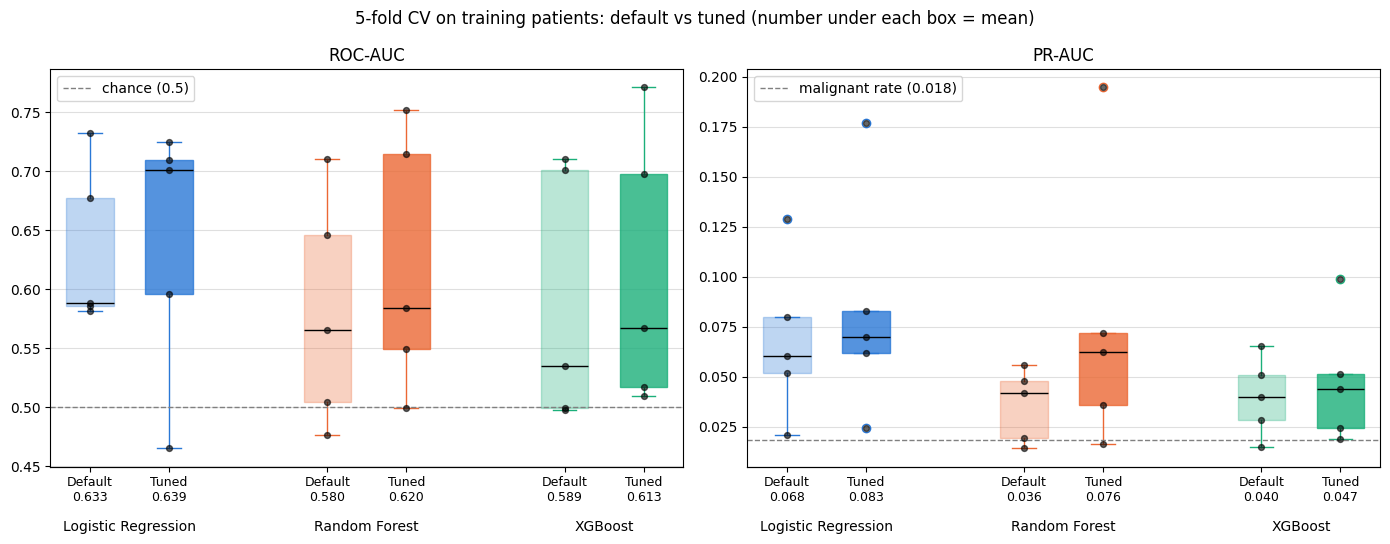

In [26]:
tuned_cv = {
    name: pd.DataFrame({
        metric: [grid.cv_results_[f'split{k}_test_{metric}'][grid.best_index_] for k in range(5)]
        for metric in SCORING
    })
    for name, grid in grids.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, metric, baseline, base_label in [
    (axes[0], 'ROC-AUC', 0.5, 'chance (0.5)'),
    (axes[1], 'PR-AUC', y_cv.mean(), f'malignant rate ({y_cv.mean():.3f})'),
]:
    ticks, ticklabels = [], []
    for m_i, name in enumerate(models):
        color = MODEL_COLORS[name]
        for v_i, (version, scores) in enumerate([('Default', default_cv[name]), ('Tuned', tuned_cv[name])]):
            pos = m_i * 3 + v_i
            ax.boxplot(scores[metric], positions=[pos], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.3 if version == 'Default' else 0.8, edgecolor=color),
                       medianprops=dict(color='black'), whiskerprops=dict(color=color), capprops=dict(color=color),
                       flierprops=dict(markeredgecolor=color))
            ax.scatter(np.full(len(scores), pos), scores[metric], s=18, color='black', alpha=0.6, zorder=3)
            ticks.append(pos)
            ticklabels.append(f"{version}\n{scores[metric].mean():.3f}")
    ax.axhline(baseline, linestyle='--', color='grey', linewidth=1, label=base_label)
    ax.set_xticks(ticks, ticklabels, fontsize=9)
    # model name centred under each default/tuned pair
    group_axis = ax.secondary_xaxis('bottom')
    group_axis.set_xticks([m_i * 3 + 0.5 for m_i in range(len(models))], [f"\n\n\n{name}" for name in models])
    group_axis.tick_params(length=0)
    ax.set_title(metric)
    ax.grid(True, axis='y', alpha=0.4)
    ax.legend(loc='upper left')
fig.suptitle('5-fold CV on training patients: default vs tuned (number under each box = mean)')
plt.tight_layout()
plt.show()

### 4. Threshold tuning (training data only)
For each tuned model, the threshold is picked from **out-of-fold** predictions on the training set: using the same 5 patient-grouped folds, each training image is scored by a model that never saw that patient. (Picking it from the final model's predictions on its own training rows would overstate recall.) We take the **highest threshold that still gives recall ≥ 0.85**, which keeps as much precision as possible while meeting the recall target.

In [27]:
TARGET_RECALL = 0.85

final_models, oof_proba, thresholds = {}, {}, {}
rows = []
for name, grid in grids.items():
    final_models[name] = grid.best_estimator_  # best params, refit on all training data
    oof_proba[name] = cross_val_predict(clone(grid.best_estimator_), X_cv, y_cv, groups=groups_cv,
                                        cv=sgkf, method='predict_proba')[:, 1]

    precision, recall, thr = precision_recall_curve(y_cv, oof_proba[name])
    # recall[:-1] lines up with thr; recall falls as the threshold rises,
    # so the last index meeting the target is the highest threshold that still does
    idx = np.where(recall[:-1] >= TARGET_RECALL)[0][-1]
    thresholds[name] = thr[idx]
    rows.append({
        'model': name,
        'OOF ROC-AUC': roc_auc_score(y_cv, oof_proba[name]),
        'OOF PR-AUC': average_precision_score(y_cv, oof_proba[name]),
        'threshold': thr[idx],
        'OOF recall': recall[idx],
        'OOF precision': precision[idx],
        '% flagged': 100 * (oof_proba[name] >= thr[idx]).mean(),
    })

pd.DataFrame(rows).set_index('model').round(4)

,OOF ROC-AUC,OOF PR-AUC,threshold,OOF recall,OOF precision,% flagged
model,,,,,,
Logistic Regression,0.6381,0.0375,0.4401,0.8544,0.0201,77.7936
Random Forest,0.6056,0.0311,0.3481,0.8544,0.0182,85.8234
XGBoost,0.5863,0.0273,0.2528,0.8641,0.0187,84.5266


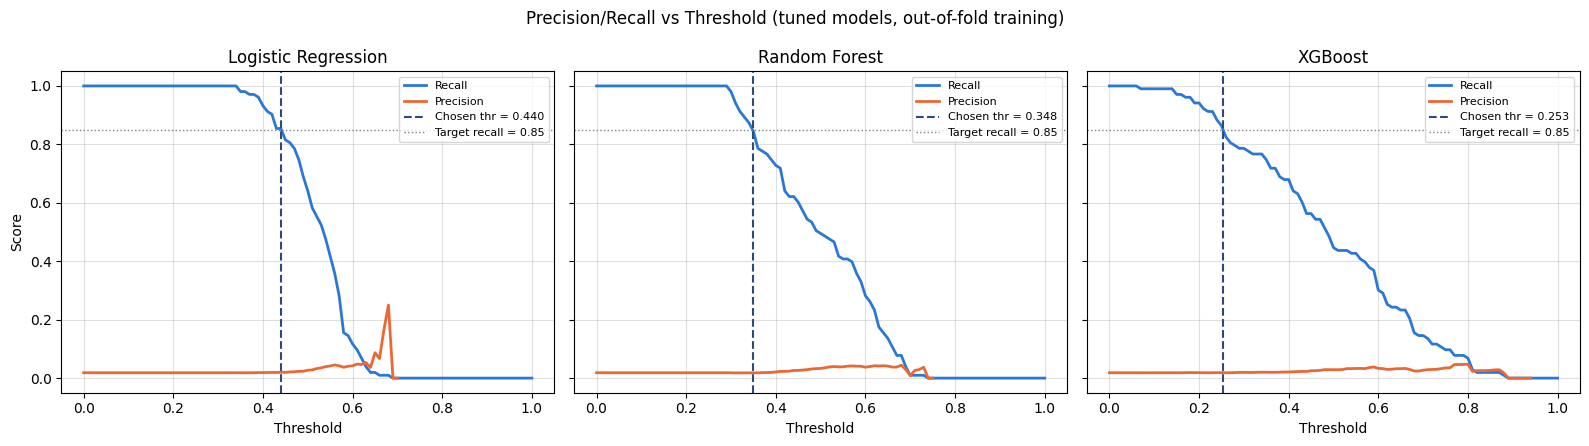

In [28]:
# Precision/recall vs threshold for each model (out-of-fold training predictions)
thr_grid = np.linspace(0, 1, 101)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, name in zip(axes, models):
    proba = oof_proba[name]
    recall_curve, precision_curve = [], []
    for t in thr_grid:
        pred = proba >= t
        tp = (pred & (y_cv == 1)).sum()
        recall_curve.append(tp / (y_cv == 1).sum())
        precision_curve.append(tp / pred.sum() if pred.sum() > 0 else np.nan)  # undefined when nothing is flagged
    ax.plot(thr_grid, recall_curve, linewidth=2, color='#2a78d6', label='Recall')
    ax.plot(thr_grid, precision_curve, linewidth=2, color='#eb6834', label='Precision')
    ax.axvline(thresholds[name], linestyle='--', color='#2e4a7a', label=f'Chosen thr = {thresholds[name]:.3f}')
    ax.axhline(TARGET_RECALL, linestyle=':', color='grey', linewidth=1, label=f'Target recall = {TARGET_RECALL}')
    ax.set_title(name)
    ax.set_xlabel('Threshold')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.4)
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Score')
fig.suptitle('Precision/Recall vs Threshold (tuned models, out-of-fold training)')
plt.tight_layout()
plt.show()

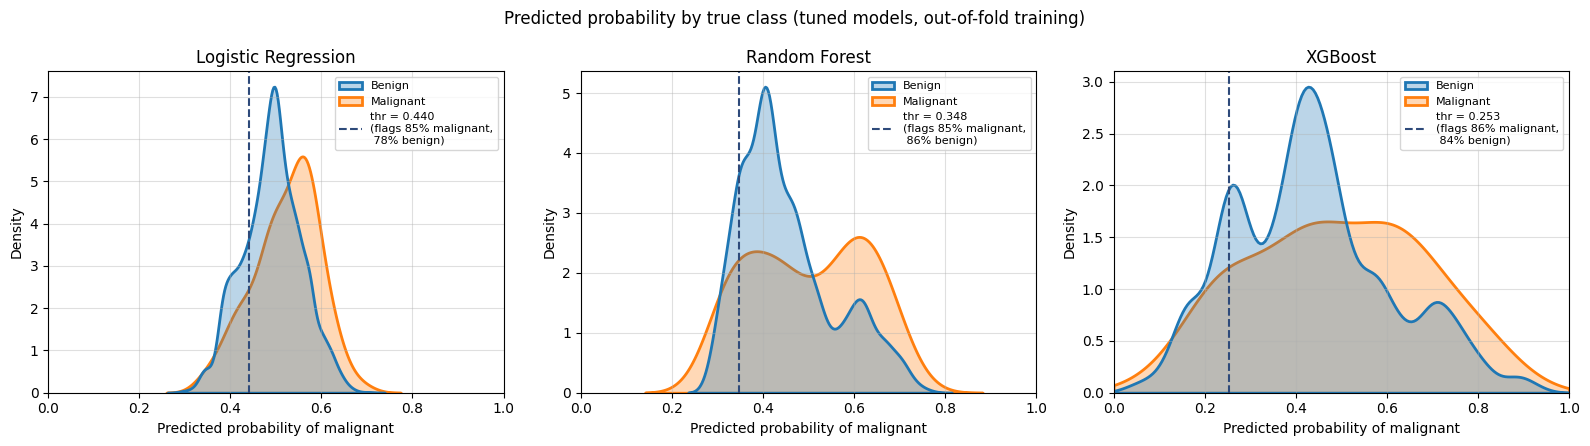

In [29]:
# Density of predicted probability by true class, per model (out-of-fold training predictions)
# common_norm=False: each class's curve integrates to 1 on its own, otherwise the
# malignant curve (~1.8% of images) would be squashed flat against the benign one
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, models):
    proba = oof_proba[name]
    dens_df = pd.DataFrame({'probability': proba, 'class': np.where(y_cv == 1, 'Malignant', 'Benign')})
    sns.kdeplot(data=dens_df, x='probability', hue='class', hue_order=['Benign', 'Malignant'],
                common_norm=False, fill=True, alpha=0.3, linewidth=2, clip=(0, 1), ax=ax)
    thr_line = ax.axvline(thresholds[name], linestyle='--', color='#2e4a7a')
    flagged_mal = (proba[y_cv == 1] >= thresholds[name]).mean()
    flagged_ben = (proba[y_cv == 0] >= thresholds[name]).mean()
    ax.legend(ax.get_legend().legend_handles + [thr_line],
              ['Benign', 'Malignant',
               f'thr = {thresholds[name]:.3f}\n(flags {flagged_mal:.0%} malignant,\n {flagged_ben:.0%} benign)'],
              loc='upper right', fontsize=8)
    ax.set_title(name)
    ax.set_xlabel('Predicted probability of malignant')
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.4)
fig.suptitle('Predicted probability by true class (tuned models, out-of-fold training)')
plt.tight_layout()
plt.show()

### 5. Validation results
Each tuned model (trained on all training patients) scored once on the untouched val patients, using its own threshold from step 4.

In [30]:
def evaluate(proba, y, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'ROC-AUC': roc_auc_score(y, proba),
        'PR-AUC': average_precision_score(y, proba),
        'threshold': threshold,
        'recall': tp / (tp + fn),
        'precision': tp / (tp + fp) if tp + fp else np.nan,
        '% flagged': 100 * pred.mean(),
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
    }

COUNT_COLS = {'TP': int, 'FN': int, 'FP': int, 'TN': int}

val_proba = {name: model.predict_proba(X_val)[:, 1] for name, model in final_models.items()}
pd.DataFrame({name: evaluate(val_proba[name], y_val, thresholds[name]) for name in models}).T.astype(COUNT_COLS).round(4)

,ROC-AUC,PR-AUC,threshold,recall,precision,% flagged,TP,FN,FP,TN
Logistic Regression,0.7497,0.0636,0.4401,0.96,0.0257,75.7085,24,1,911,299
Random Forest,0.7044,0.0696,0.3481,0.96,0.0204,95.4656,24,1,1155,55
XGBoost,0.6619,0.0529,0.2528,0.96,0.0210,92.5506,24,1,1119,91


### Feature importance (tuned models)
Not directly comparable across models, so read each panel on its own:
- **Logistic Regression**: coefficients (log-odds per unit; age is standardized, so its unit is 1 SD of age). Sign shows direction.
- **Random Forest**: impurity-based importance, which tends to favour continuous features like age.
- **XGBoost**: gain-based importance (average loss reduction from splits on that feature).

Site is one-hot encoded, so each site category gets its own bar.

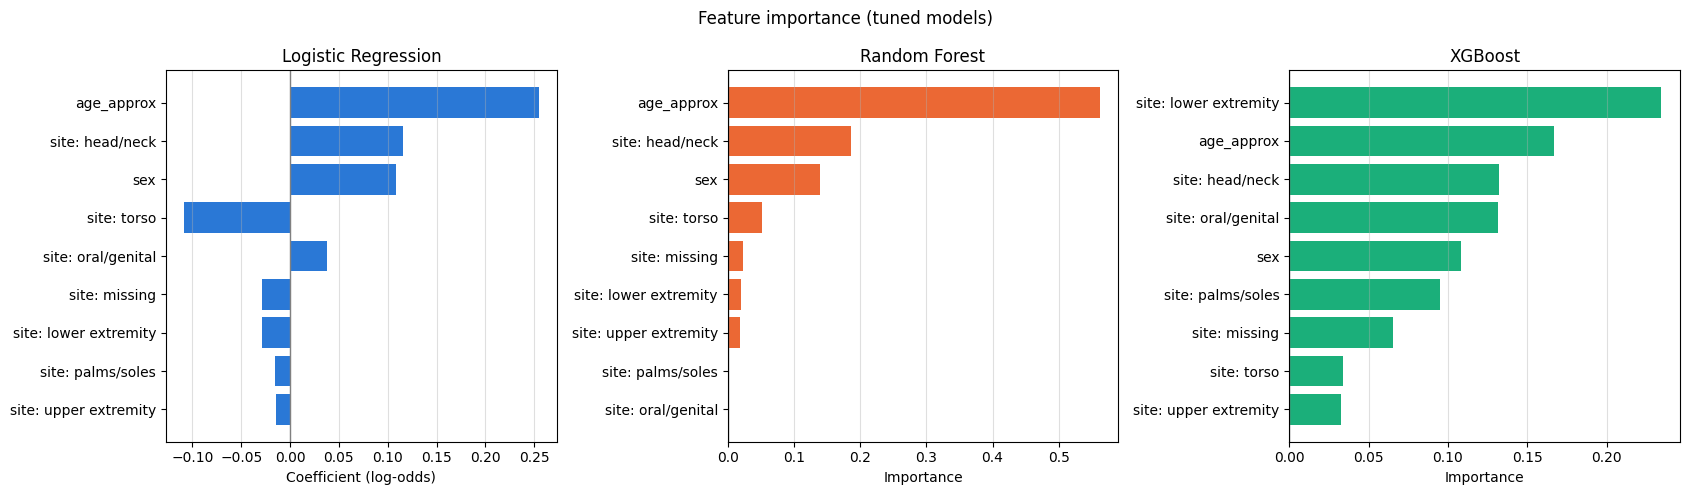

In [31]:
def clean_names(pipe):
    return [n.replace('site__anatom_site_general_challenge_', 'site: ').replace('age__', '').replace('remainder__', '')
            for n in pipe.named_steps['encode'].get_feature_names_out()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, name in zip(axes, models):
    pipe = final_models[name]
    est = pipe.named_steps['model']
    if name == 'Logistic Regression':
        values, xlabel = est.coef_[0], 'Coefficient (log-odds)'
    else:
        values, xlabel = est.feature_importances_, 'Importance'
    imp = pd.Series(values, index=clean_names(pipe))
    imp = imp.reindex(imp.abs().sort_values().index)
    ax.barh(imp.index, imp.values, color=MODEL_COLORS[name])
    ax.axvline(0, color='grey', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis='x', alpha=0.4)
fig.suptitle('Feature importance (tuned models)')
plt.tight_layout()
plt.show()

In [32]:
# One CSV per model: metadata_val_predictions_lr.csv, metadata_val_predictions_rf.csv
for name, short in [('Logistic Regression', 'lr'), ('Random Forest', 'rf')]:
    val_report = val_df[['image_name', 'patient_id', 'target']].copy()
    val_report['probability'] = val_proba[name]
    val_report['classification'] = (val_proba[name] >= thresholds[name]).astype(int)
    val_report.to_csv(f'metadata_val_predictions_{short}.csv', index=False)

# 6. Test Set Results (all tuned models)
Final, one-off evaluation on `test_labels.csv`, a separate set of patients never used for training, tuning or threshold choice. Each model is its tuned version (trained on all training patients) with its own threshold from step 4. Test data gets the same cleaning as training; encoding happens inside each pipeline.

In [33]:
test_labels = pd.read_csv(TEST_LABELS_CSV)

# Same cleaning as train_labels_clean
test_labels_clean = test_labels.copy()
test_labels_clean["sex"] = test_labels_clean["sex"].map({"male": 1, "female": 0})
test_labels_clean["anatom_site_general_challenge"] = test_labels_clean["anatom_site_general_challenge"].fillna("missing")
test_labels_clean = test_labels_clean.drop(["diagnosis", "benign_malignant"], axis=1)

X_test = test_labels_clean.drop(columns=["image_name", "patient_id", "target"])
y_test = test_labels_clean["target"]

overlap = set(test_labels_clean['patient_id']) & set(train_labels_clean['patient_id'])
print(f"Test: {len(test_labels_clean)} images, {test_labels_clean['patient_id'].nunique()} patients, "
      f"{y_test.sum()} malignant ({y_test.mean():.2%})")
print(f"Patients shared with train_labels: {len(overlap)}")

Test: 1988 images, 106 patients, 31 malignant (1.56%)
Patients shared with train_labels: 0


In [34]:
test_proba = {name: model.predict_proba(X_test)[:, 1] for name, model in final_models.items()}
pd.DataFrame({name: evaluate(test_proba[name], y_test, thresholds[name]) for name in models}).T.astype(COUNT_COLS).round(4)

,ROC-AUC,PR-AUC,threshold,recall,precision,% flagged,TP,FN,FP,TN
Logistic Regression,0.6793,0.0378,0.4401,0.8710,0.0171,79.6278,27,4,1556,401
Random Forest,0.6853,0.0336,0.3481,0.9677,0.0157,96.3783,30,1,1886,71
XGBoost,0.6608,0.0326,0.2528,0.9677,0.0163,92.5553,30,1,1810,147


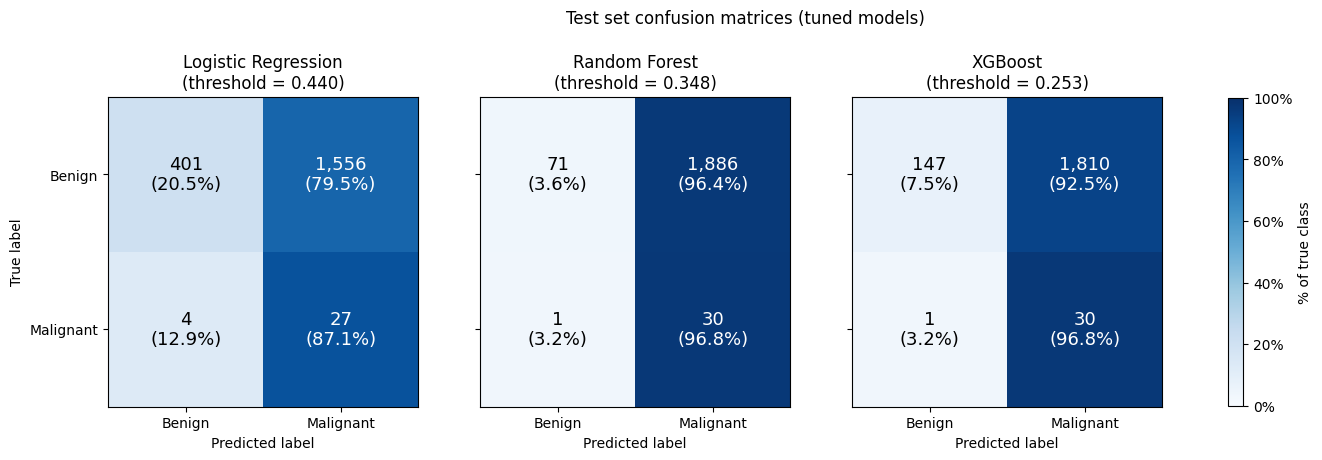

In [35]:
# Test confusion matrices: counts + % of each true class (row).
# Colour follows the row %, so the small malignant row is as readable as the benign one.
labels = ['Benign', 'Malignant']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, (test_proba[name] >= thresholds[name]).astype(int))
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_pct[i, j]:.1%})", ha='center', va='center', fontsize=13,
                    color='white' if cm_pct[i, j] > 0.5 else 'black')
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels if ax is axes[0] else [])
    ax.set_xlabel('Predicted label')
    ax.set_title(f'{name}\n(threshold = {thresholds[name]:.3f})')
axes[0].set_ylabel('True label')
cbar = fig.colorbar(im, ax=axes, format=lambda v, _: f'{v:.0%}', shrink=0.8)
cbar.set_label('% of true class')
fig.suptitle('Test set confusion matrices (tuned models)')
plt.show()

In [36]:
# One CSV per model: metadata_test_predictions_lr.csv, metadata_test_predictions_rf.csv
for name, short in [('Logistic Regression', 'lr'), ('Random Forest', 'rf')]:
    test_report = test_labels_clean[['image_name', 'patient_id', 'target']].copy()
    test_report['probability'] = test_proba[name]
    test_report['classification'] = (test_proba[name] >= thresholds[name]).astype(int)
    test_report.to_csv(f'metadata_test_predictions_{short}.csv', index=False)

In [37]:
# Copy the four prediction CSVs to Google Drive (Colab only)
import shutil

PRED_CSVS = [f'metadata_{split}_predictions_{short}.csv' for split in ('val', 'test') for short in ('lr', 'rf')]

if os.path.isdir('/content'):
    from google.colab import drive
    drive.mount('/content/drive')  # no-op if already mounted in the setup cell

    DRIVE_OUT_DIR = '/content/drive/MyDrive/metadata_predictions'  # adjust to save somewhere else in Drive
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    for csv in PRED_CSVS:
        shutil.copy(csv, DRIVE_OUT_DIR)
        print('saved', os.path.join(DRIVE_OUT_DIR, csv))
else:
    print('Not on Colab -- CSVs are in', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved /content/drive/MyDrive/metadata_predictions/metadata_val_predictions_lr.csv
saved /content/drive/MyDrive/metadata_predictions/metadata_val_predictions_rf.csv
saved /content/drive/MyDrive/metadata_predictions/metadata_test_predictions_lr.csv
saved /content/drive/MyDrive/metadata_predictions/metadata_test_predictions_rf.csv
